In [39]:
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
# SUS / RTLX data (one row per participant per condition)
sus_rtlx_df = pd.read_csv("sus_rtlx_long.csv")

In [41]:
SCORE_CONDITIONS = ["standard", "plugin", "voice_control"]

sus_wide  = sus_rtlx_df.pivot(index="participant", columns="condition", values="SUS")[SCORE_CONDITIONS]
rtlx_wide = sus_rtlx_df.pivot(index="participant", columns="condition", values="RTLX")[SCORE_CONDITIONS]

print("SUS — mean (SD)")
for c in SCORE_CONDITIONS:
    print(f"  {c}: M = {sus_wide[c].mean():.2f}, SD = {sus_wide[c].std():.2f}")

print("\nRTLX — mean (SD)")
for c in SCORE_CONDITIONS:
    print(f"  {c}: M = {rtlx_wide[c].mean():.2f}, SD = {rtlx_wide[c].std():.2f}")

SUS — mean (SD)
  standard: M = 88.50, SD = 9.86
  plugin: M = 61.67, SD = 13.75
  voice_control: M = 47.83, SD = 19.66

RTLX — mean (SD)
  standard: M = 11.72, SD = 9.57
  plugin: M = 41.39, SD = 12.74
  voice_control: M = 52.28, SD = 11.08


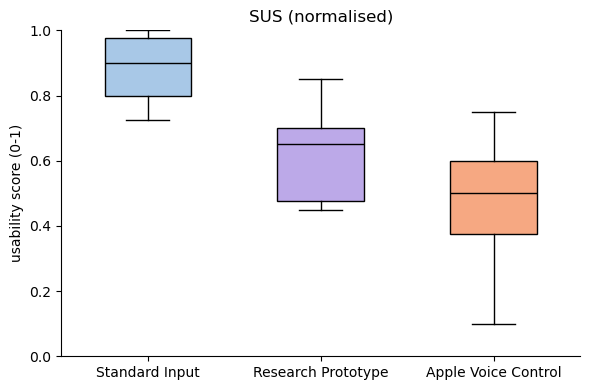

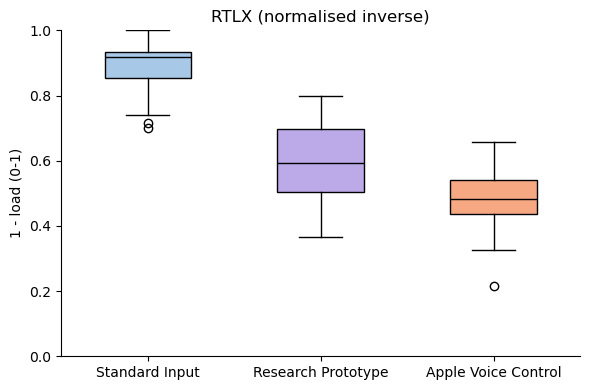

In [42]:
# SUS and RTLX — normalised and normalised inverse
# SUS: divide by 100 so scores sit on 0-1 (higher = more usable)
# RTLX normalised inverse: (100 - score) / 100 so higher = less load (same direction as SUS)

SCORE_COLORS = {"standard": "#a8c8e7", "voice_control": "#f6a882", "plugin": "#bca9e8"}

# SCORE_COLORS = {"standard": "#f5f5f5", "voice_control": "#c7c7c7", "plugin": "#999999"}

SCORE_LABELS = {"standard": "Standard Input", "voice_control": "Apple Voice Control", "plugin": "Research Prototype"}

sus_norm  = sus_wide / 100
rtlx_norm_inv = (100 - rtlx_wide) / 100

for wide_df, label, ylabel in [
    (sus_norm,     "SUS (normalised)",          "usability score (0-1)"),
    (rtlx_norm_inv,"RTLX (normalised inverse)", "1 - load (0-1)"),
]:
    data = [wide_df[c].values for c in SCORE_CONDITIONS]

    fig, ax = plt.subplots(figsize=(6, 4))
    bp = ax.boxplot(data, patch_artist=True, widths=0.5)

    for patch, c in zip(bp["boxes"], SCORE_CONDITIONS):
        patch.set_facecolor(SCORE_COLORS[c])
        patch.set_alpha(1)
    for median in bp["medians"]:
        median.set_color("black")

    ax.set_ylim(0, 1)
    ax.set_xticklabels([SCORE_LABELS[c] for c in SCORE_CONDITIONS])
    ax.set_ylabel(ylabel)
    ax.set_title(label)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()